In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("08-email_classification_svm.csv")

In [3]:
df.head()

,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


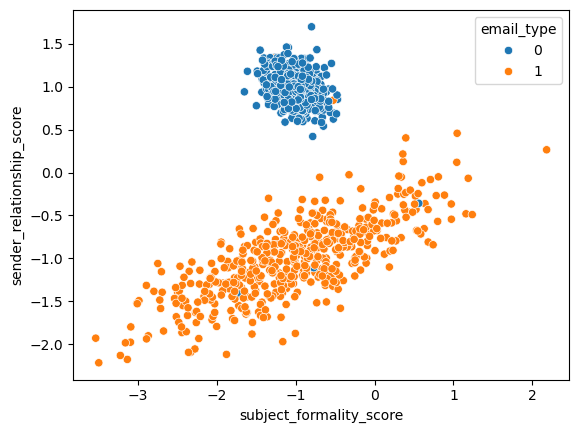

In [5]:
sns.scatterplot(x=df["subject_formality_score"] , y=df["sender_relationship_score"], hue = df["email_type"])
plt.show()

In [6]:
X = df[["subject_formality_score", "sender_relationship_score"]].values
y = df["email_type"].values

In [7]:
X


array([[-1.49678965,  0.77925822],
       [-1.21760978,  0.88960104],
       [-0.37594518, -0.82332435],
       ...,
       [-1.36975007,  1.0222785 ],
       [-1.1850392 , -1.20266647],
       [-1.17835511,  1.08298346]], shape=(1000, 2))

In [8]:
y

array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [11]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [12]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([800, 2]) torch.Size([800, 1])
torch.Size([200, 2]) torch.Size([200, 1])


In [13]:
from torch import nn

In [14]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(in_features = 2, out_features=5)
        self.layer_2 = nn.Linear(in_features = 5, out_features=1)
    def forward(self,x):
        return self.layer_2(self.layer_1(x))

In [15]:
model_0 = ClassificationModel()

In [16]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.01)

In [17]:
def calculate_accuracy(y_test, y_pred):
    correct = torch.eq(y_test,y_pred).sum().item()
    accuracy = (correct / len(y_test)) *100
    return accuracy

In [18]:
y_logits = model_0(X_test)

In [19]:
y_pred_probs = torch.sigmoid(y_logits)

In [20]:
y_preds = torch.round(y_pred_probs)

In [21]:
calculate_accuracy(y_test,y_preds)

65.5

In [22]:
torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
    model_0.train()
    y_logits = model_0(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    loss = loss_fn(y_logits, y_train)
    acc = calculate_accuracy(y_test = y_train, y_pred = y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_accuracy(y_test = y_test, y_pred = test_pred)

        if epoch % 5 == 0:
            print(f"Epoch: {epoch}, Loss: {loss}, Accuracy: {acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}")
        

Epoch: 0, Loss: 0.6584627032279968, Accuracy: 64.0, Test Loss: 0.6615943908691406, Test Accuracy: 66.0
Epoch: 5, Loss: 0.6459587812423706, Accuracy: 65.125, Test Loss: 0.648438572883606, Test Accuracy: 68.0
Epoch: 10, Loss: 0.6338747143745422, Accuracy: 65.75, Test Loss: 0.6357243657112122, Test Accuracy: 69.5
Epoch: 15, Loss: 0.622161865234375, Accuracy: 66.875, Test Loss: 0.6234021186828613, Test Accuracy: 70.0
Epoch: 20, Loss: 0.6107777953147888, Accuracy: 68.375, Test Loss: 0.611427903175354, Test Accuracy: 70.5
Epoch: 25, Loss: 0.5996849536895752, Accuracy: 70.5, Test Loss: 0.5997635126113892, Test Accuracy: 71.5
Epoch: 30, Loss: 0.5888508558273315, Accuracy: 71.625, Test Loss: 0.5883752107620239, Test Accuracy: 72.5
Epoch: 35, Loss: 0.5782469511032104, Accuracy: 73.625, Test Loss: 0.5772337913513184, Test Accuracy: 74.5
Epoch: 40, Loss: 0.5678486227989197, Accuracy: 76.375, Test Loss: 0.5663139820098877, Test Accuracy: 76.5
Epoch: 45, Loss: 0.557634711265564, Accuracy: 79.0, Test

In [23]:
import numpy as np
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # toplam efektif ağırlık = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.layer_1.weight.detach().numpy()       # shape (5,2)
    b1 = model.layer_1.bias.detach().numpy()         # shape (5,)
    W2 = model.layer_2.weight.detach().numpy()       # shape (1,5)
    b2 = model.layer_2.bias.detach().numpy()[0]      # shape (1,)

    # efektif W ve b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # iki feature'ın ağırlığı

    # efektif b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X aralığı
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Doğru denkleminden x2 hesaplama
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Noktalar
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

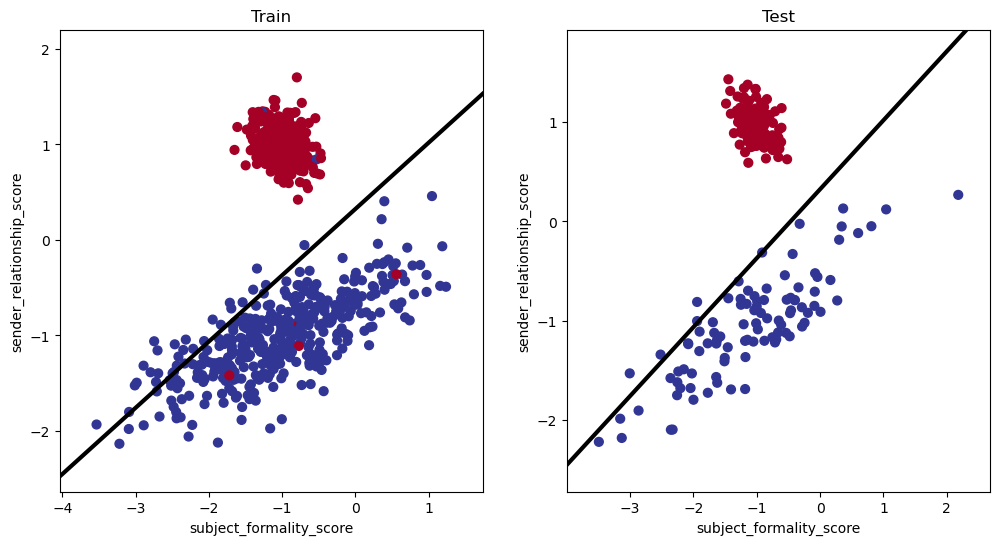

In [24]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model_0, X_test, y_test)

plt.show()